PINN Example: Two dimensional Navier-Stokes Equation
===

Summary:
---

---

This example is taken from Maziar Raissi's example [here](https://maziarraissi.github.io/PINNs/) which accompanies his original [work](https://www.sciencedirect.com/science/article/pii/S0021999118307125).

The [two dimensional Navier-Stokes equations](https://en.wikipedia.org/wiki/Navier%E2%80%93Stokes_equations) we will use in this example is:

$$
\partial u_t + \lambda_1 (u \partial_x u + v \partial_y u) = -p_x + \lambda_2 ( \partial_{x,x}u + \partial_{y,y}u),
$$
$$
\partial u_t + \lambda_1 (u \partial_x v + v \partial_y v) = -p_y + \lambda_2 ( \partial_{x,x}v + \partial_{y,y}v),
$$

where $u(x, y, t)$ denotes the x-component of the velocity field, $v(x, y, t)$ the y-component, and $p(x, y, t)$ the pressure. We can simplify the problem a bit more by using the continuity equation to infer that:

$$
\partial_x u + \partial_y v = 0.
$$

We can make an assumption that there exists a scalar field, $\psi(x, y, t)$, which describes these velocity components such that:

$$
u = \partial_y \psi,
$$
$$
v = - \partial_x \psi,
$$

which automatically guarantees the continuity equation is respected.  In this example we will assume the velocity field ($u$ and $v$) can be measured as a function of position ($x$ and $y$) and time ($t$); however, we do not know the pressure or the coefficients, $\vec{\lambda} = \langle \lambda_1, \lambda_2 \rangle$.

In this example,

$$
\mathcal{N}_1[u, v; \vec{\lambda}] = \lambda_1 (u \partial_x u + v \partial_y u) + p_x - \lambda_2 ( \partial_{x,x}u + \partial_{y,y}u),
$$
$$
\mathcal{N}_2[u, v; \vec{\lambda}] = \lambda_1 (u \partial_x v + v \partial_y v) + p_y - \lambda_2 ( \partial_{x,x}v + \partial_{y,y}v),
$$

where we musy satisfy both.  To solve this we will create a neural network that accepts ($x$, $y$, and $t$) and has 2 outputs ($\psi(x, y, t)$ and $p(x, y, t)$).

The [data used in this example](https://github.com/maziarraissi/PINNs/tree/master/main/Data) corresponds to incompressible flow past a circular cylinder which exhibits a rich dynamic behavior and transitions for different regimes of the Reynolds number, ${\rm Re} = u_{\infty} D / \nu$.  Here, $u_{\infty}$ is the free stream velocity far from the cylinder, $D$ is its diameter, and $\nu$ is the fluid's kinematic viscosity.  In this example, $u_{\infty} D / \nu = 1$, $D = 1$, and $\nu = 0.01$; the system exhibits a periodic steady state behavior characterized by asymmetrical vortex shedding pattern in the cylinder wake, known as the [Kármán vortex street](https://en.wikipedia.org/wiki/K%C3%A1rm%C3%A1n_vortex_street).


![](https://upload.wikimedia.org/wikipedia/commons/b/b4/Vortex-street-animation.gif)


👉 This is a useful minimal example since the known behavior is highly non-trivial to solve.

The PINN we are going to create looks something like this:

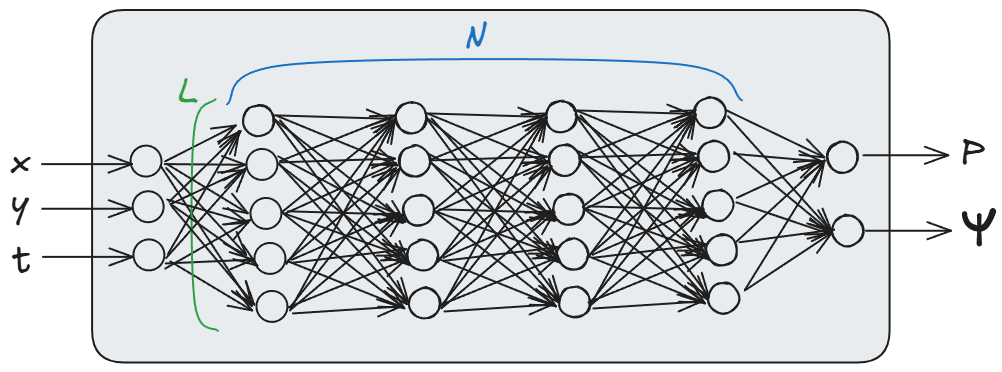

Key Points
---

---
 
1. Consider using a [normalization layer](https://keras.io/api/layers/preprocessing_layers/numerical/normalization/) to help training.

⚠ In principle, training should be halted based on when the loss measured on a held-out validation set; this is not done here, though it is not difficult to implement.  For illustration purposes the approach used below is sufficient.

In [ ]:
import os
import tqdm
import torch

import torch.nn as nn
import numpy as np
import plotly.graph_objects as go
import scipy.io as sio

from numpy.typing import NDArray
from plotly.subplots import make_subplots
from pyDOE import lhs
from typing import Union, Any, ClassVar

In [ ]:
%load_ext watermark
%watermark -t -m -v --iversions

# 1. Identification: Data-driven Discovery of PDEs

Now we will try to use training data to discover the value of the PDE's parameters.  Here, we will use [uncorrupted, simulated data](https://github.com/maziarraissi/PINNs/tree/master/appendix/Data) where $\nu = 0.01$, but you can add noise to this to explore what happens.  It turns out the PINN is pretty robust against random noise since it tries to fit an "average".  However, we would anticipate that if this noise is not random (either due to bias, or the governing equation actually having other terms we do not know about) then results may vary.  Still, this approach yields the "best fit" of the PINN and its parameters to the given data.

In this approach, we do not need to assume any boundary or initial conditions.  We just need the raw training data, much the same way we would approach solving this problem with a conventional deep feed-forward network.  The difference is that here the loss is a combination of prediction error (convention and PINN) plus the deviation from the PDE (PINN only) at these points.  In principle, we do not need to use these training points as the collocation points since we can assess PDE deviation at any point in the [x, y, t] domain; however, it is convenient to do since we can reuse the field calculation for the derivatives.

Programming Notes

---

1. In order to use pytorch to optimize these parameters ($\vec{\lambda}$) we need to add them as "parameters" to our NN model so that optimizer can operate on them correctly.

In [ ]:
# For reproducibility, let's set these seeds
np.random.seed(1234)
_ = torch.manual_seed(0)

## Load measured data

In [ ]:
data = sio.loadmat('./data/cylinder_nektar_wake.mat')

In [ ]:
# The fluid field was measured on a regular grid of [x, y, t]
U_star = data['U_star'] # N x 2 x T
P_star = data['p_star'] # N x T
t_star = data['t'] # T x 1
X_star = data['X_star'] # N x 2

N = X_star.shape[0]
T = t_star.shape[0]

# Rearrange Data
XX = np.tile(X_star[:, 0:1], (1, T)) # N x T
YY = np.tile(X_star[:, 1:2], (1, T)) # N x T
TT = np.tile(t_star, (1,N)).T # N x T

UU = U_star[:,0,:] # N x T
VV = U_star[:,1,:] # N x T
PP = P_star # N x T

# Flatten this into a long array
x = XX.flatten()[:,None] # NT x 1
y = YY.flatten()[:,None] # NT x 1
t = TT.flatten()[:,None] # NT x 1

u = UU.flatten()[:,None] # NT x 1
v = VV.flatten()[:,None] # NT x 1
p = PP.flatten()[:,None] # NT x 1

# Select a random subsample to use as the training data
N_f = 5000
idx = np.random.choice(N*T, N_f, replace=False)

x_train = x[idx,:]
y_train = y[idx,:]
t_train = t[idx,:]
u_train = u[idx,:]
v_train = v[idx,:]

# Select training data
X_train = np.hstack((x_train, y_train, t_train))
uv_train = np.hstack((u_train, v_train))

In [ ]:
def plot(x, y, t, p, u, v):
    """Plot field over time."""
    # Create figure
    fig = make_subplots(rows=1, cols=3,
                        specs=[[{'is_3d': True}, {'is_3d': True}, {'is_3d': True}]],
                        subplot_titles=['p(x, y, t)', 'u(x, y, t)', 'v(x, y, t)'],
                        )

    # Add traces, one for each slider step
    t_ = []
    for step in np.arange(0, len(t), 5):
        t_.append(step)
        fig.add_trace(go.Surface(z=p[:, step:step+1].reshape((len(y), len(x))), x=x, y=y), 1, 1) # order of (len(y), len(x)) is just how the data was provided
        fig.add_trace(go.Surface(z=u[:, step:step+1].reshape((len(y), len(x))), x=x, y=y), 1, 2) # order of (len(y), len(x)) is just how the data was provided
        fig.add_trace(go.Surface(z=v[:, step:step+1].reshape((len(y), len(x))), x=x, y=y), 1, 3) # order of (len(y), len(x)) is just how the data was provided

    # Make first trace visible
    fig.data[0].visible = True

    # Create and add slider
    steps = []
    for i in range(len(fig.data) // 3):
        step = dict(
            method="update",
            args=[{"visible": [False] * 3 * len(fig.data)},
                {"title": f"Field at time: {t[t_[i]]}"}],  # layout attribute
        )

        for j in range(3):
            step["args"][0]["visible"][3*i + j] = True  # Toggle i'th trace to "visible"

        steps.append(step)

    sliders = [dict(
        active=0,
        currentvalue={"prefix": "Frequency: "},
        # pad={"t": 50},
        steps=steps
    )]

    fig.update_layout(
        sliders=sliders
    )

    fig.show()

In [ ]:
plot(x=np.unique(X_star[:, 0]), y=np.unique(X_star[:, 1]), t=t_star.flatten(), p=P_star, u=UU, v=VV)

## Solve

In [ ]:
import mlflow

# If you are not using the Docker devcontainer you might need to point to your MLFlow server
# The start_jupyter.sh automatically sets the MLFLOW_TRACKING_URI to match the start_mlflow.sh script
# mlflow.set_tracking_uri('http://127.0.0.1:4342') 

In [ ]:
class Model_Discovery(nn.Module):
    """
    Fully connected neural network that acts as the surrogate function with free fitting parameters we are going to "discover" included.
    """
    model: ClassVar[nn.Module]
    _lambda_1: nn.Parameter
    _lambda_2: nn.Parameter
    
    def __init__(self, inputs: int, outputs: int, layers: list[int], guesses: list[float] = [0.1, 0.1], activation: str = 'Tanh', dtype: torch.dtype = torch.float32) -> None:
        """
        Instantiate the neural network.

        Parameters
        ----------
        inputs : int
            Number of inputs to the model.

        outputs : int
            Number of outputs from the model.
            
        layers : list(int)
            An ordered list of the size of each dense layer in the network to create.

        guesses : list(float), optional(default=[0.1, 0.1])
            Initial guesses for `lambda_1` and `lambda_2`.

        activation : str, optional(default='Tanh')
            Activation function (by name) to use in each layer.
            
        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        super().__init__()
        setattr(self, "layers", layers)

        seq = [nn.Linear(in_features=inputs, out_features=layers[0], dtype=dtype), getattr(nn, activation)() ]
        for i in range(1, len(layers)):
            seq += [nn.Linear(in_features=layers[i-1], out_features=layers[i], dtype=dtype), getattr(nn, activation)() ]
        seq += [nn.Linear(in_features=layers[-1], out_features=outputs, dtype=dtype)]

        model = nn.Sequential(*seq)
        setattr(self, "model", model)

        # Add these fitting parameters to the model - these get automatically picked up by calls to 
        # `model.parameters()` that we give to the optimizer later.
        setattr(self, "_lambda_1", nn.Parameter(torch.tensor(guesses[0], requires_grad=True, dtype=dtype)))
        setattr(self, "_lambda_2", nn.Parameter(torch.tensor(guesses[1], requires_grad=True, dtype=dtype)))

    def forward(self, x: torch.tensor) -> torch.tensor:
        """
        Perform a forward pass through the model.

        Parameters
        ----------
        x : torch.tensor
            Input to model.

        Returns
        -------
        output : torch.tensor
            Prediction of model.
        """
        output = self.model(x)
        return output

    @property
    def lambda_1(self):
        """Convenience function to access lambda 1."""
        return self._lambda_1.detach().cpu().numpy()

    @property
    def lambda_2(self):
        """Convenience function to access lambda 2."""
        return self._lambda_2.detach().cpu().numpy()

In [ ]:
class NavierStokes_Discovery_Loss(nn.Module):
    """
    PINN loss functions for discovering Navier-Stokes' equation.
    """
    _X_f_x: ClassVar[torch.tensor]
    _X_f_y: ClassVar[torch.tensor]
    _X_f_t: ClassVar[torch.tensor]
    _u_f: ClassVar[torch.tensor]
    _v_f: ClassVar[torch.tensor]
    
    def __init__(
        self, 
        X_f: NDArray[np.floating],
        uv_f: NDArray[np.floating],
        device: str = 'cpu',
        dtype: torch.dtype = torch.float32
    ) -> None:
        """
        Instantiate the loss.
        
        Parameters
        ----------
        X_f : ndarray(float, ndim=2)
            Column of [x, t] pairs corresponding to the points where consistency with PDE conservation will be assessed "inside" the domain.

        uv_f : ndarray(float, ndim=2)
            Column of field values [u, v] measured at `X_f` points.

        device : str, optional(default='cpu')
            Device to place the tensors on.  The model will also be moved here, if it is not there already, to ensure optimal speed.
            
        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        super().__init__()

        setattr(self, "device", device)
        
        # Sanity checks
        assert(X_f.ndim == 2), 'X_f should be two-dimensional'
        assert(uv_f.ndim == 2), 'uv_f should be a column'
        assert(len(uv_f) == len(X_f)), 'uv_f and X_f should have the same length'

        # Set internal attributes and convert ndarray -> torch.tensor.
        # It is convenient to break up columns of X into [x, y, t] for when we need to take derivatives with respect to each of these individual variables.
        setattr(self, "_X_f_x", torch.tensor(X_f[:, 0:1], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_X_f_y", torch.tensor(X_f[:, 1:2], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_X_f_t", torch.tensor(X_f[:, 2:3], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_u_f", torch.tensor(uv_f[:, 0:1], requires_grad=True, dtype=dtype).to(self.device))
        setattr(self, "_v_f", torch.tensor(uv_f[:, 1:2], requires_grad=True, dtype=dtype).to(self.device))

    def forward(self, model: nn.Module) -> tuple[torch.tensor, torch.tensor, torch.tensor]:
        """
        Compute the loss.

        Parameters
        ----------
        model : nn.Module
            PINN model.

        Returns
        -------
        total_loss : torch.tensor
            Total loss (located on `device`).
            
        pde_loss : torch.tensor
            Partial differential equation loss (located on `device`).
        
        fit_loss : torch.tensor
            Fit (data) loss (located on `device`).
        """
        # Put model in training mode and move to device
        model.to(device=self.device)
        model.train()

        def _predict(x: torch.tensor, y: torch.tensor, t: torch.tensor) -> torch.tensor:
            return model(torch.concat([x, y, t], axis=1))

        # https://discuss.pytorch.org/t/pytorch-adam-vs-tensorflow-adam/74471/4
        psi_p = _predict(x=self._X_f_x, y=self._X_f_y, t=self._X_f_t)
        psi = psi_p[:, 0:1]
        p = psi_p[:, 1:2]

        # Compute the PDE loss
        u = torch.autograd.grad(psi, self._X_f_y, grad_outputs=torch.ones_like(psi), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        v = -torch.autograd.grad(psi, self._X_f_x, grad_outputs=torch.ones_like(psi), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        p_x = torch.autograd.grad(p, self._X_f_x, grad_outputs=torch.ones_like(p), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        p_y = torch.autograd.grad(p, self._X_f_y, grad_outputs=torch.ones_like(p), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        u_t = torch.autograd.grad(u, self._X_f_t, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        u_x = torch.autograd.grad(u, self._X_f_x, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        u_y = torch.autograd.grad(u, self._X_f_y, grad_outputs=torch.ones_like(u), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        v_t = torch.autograd.grad(v, self._X_f_t, grad_outputs=torch.ones_like(v), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        v_x = torch.autograd.grad(v, self._X_f_x, grad_outputs=torch.ones_like(v), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        v_y = torch.autograd.grad(v, self._X_f_y, grad_outputs=torch.ones_like(v), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        u_xx = torch.autograd.grad(u_x, self._X_f_x, grad_outputs=torch.ones_like(u_x), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        u_yy = torch.autograd.grad(u_y, self._X_f_y, grad_outputs=torch.ones_like(u_y), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        v_xx = torch.autograd.grad(v_x, self._X_f_x, grad_outputs=torch.ones_like(v_x), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        v_yy = torch.autograd.grad(v_y, self._X_f_y, grad_outputs=torch.ones_like(v_y), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]

        f_u = u_t + model._lambda_1*(u*u_x + v*u_y) + p_x - model._lambda_2*(u_xx + u_yy)
        f_v = v_t + model._lambda_1*(u*v_x + v*v_y) + p_y - model._lambda_2*(v_xx + v_yy)

        pde_loss = torch.mean(
            torch.square(f_u)
        ) + \
        torch.mean(
            torch.square(f_v)
        )

        # Compute the fitting loss
        fit_loss = torch.mean(
            torch.square(
                u - self._u_f
            )
        ) + \
        torch.mean(
            torch.square(
                v - self._v_f
            )
        )

        # The total loss is the sum of all losses
        total_loss = pde_loss + fit_loss

        return total_loss, pde_loss, fit_loss

In [ ]:
class PINN_Discovery_NavierStokes:
    """
    Discover the Navier-Stokes' equation.
    """
    loss: ClassVar[nn.Module]
    model: ClassVar[nn.Module]
    mlflow_experiment: ClassVar[str]
    filename: ClassVar[str]
    dtype: ClassVar[torch.dtype]
    device: ClassVar[str]
    
    def __init__(
        self, 
        layers: list[int],
        X_f: NDArray[np.floating], 
        uv_f: NDArray[np.floating], 
        guesses: list[float] = [0.0, 0.0],
        activation: str = 'Tanh',
        experiment_name: str = 'intro-navier-stokes-discovery-pt',
        dtype: torch.dtype = torch.float32
    ) -> None:
        """
        Instantiate the PINN.

        Parameters
        ----------
        layers : list(int)
            An ordered list of the size of each dense layer in the network to create.

        X_f : ndarray(float, ndim=2)
            Column of [x, t] pairs corresponding to the points where consistency with PDE conservation will be assessed "inside" the domain.

        uv_f : ndarray(float, ndim=2)
            Column of field values measured at `X_f` points.

        guesses : list(float), optional(default=[0.0, 0.0])
            Initial guesses for `lambda_1` and `lambda_2`.

        activation : str, optional(default='Tanh')
            Activation function (by name) to use in each layer.

        experiment_name : str, optional(default='intro-navier-stokes-discovery-pt')
            MLFlow experiment name; if your selected one exists, choose a new one.

        dtype : torch.dtype, optional(default=torch.float32)
            Precision to train neural net with.
        """
        # Set up a new experiment in MLFlow
        mlflow_experiment = mlflow.create_experiment(experiment_name)
        setattr(self, "mlflow_experiment", mlflow_experiment)

        setattr(self, "filename", "pinn-navier-stokes.pt")
        setattr(self, "dtype", dtype)

        # Automatically use the GPU is available
        device = ('cuda' if torch.cuda.is_available() else 'cpu')
        setattr(self, "device", device)
        
        loss = NavierStokes_Discovery_Loss(X_f=X_f, uv_f=uv_f, device=self.device, dtype=self.dtype)
        model = Model_Discovery(inputs=3, outputs=2, layers=layers, guesses=guesses, activation=activation, dtype=self.dtype)
        model.to(device=self.device)
        
        setattr(self, "loss", loss)
        setattr(self, "model", model)

    def predict(self, X: NDArray[np.floating], model=None) -> tuple[NDArray[np.floating], NDArray[np.floating], NDArray[np.floating], NDArray[np.floating]]:
        """
        Predict the field (psi and p) value at given [x, y, t] values.

        This is intended to be used after training on new, unseen data provided in a numpy format instead of torch tensor.

        Parameters
        ----------
        X : ndarray(float, ndim=2)
            Column of [x, y, t] points where we should predict the field.

        Returns
        -------
        psi : ndarray(float, ndim=2)
            Psi at each point.

        u : ndarray(float, ndim=2)
            X velocity field component at each point.

        v : ndarray(float, ndim=2)
            Y velocity field component at each point.

        p : ndarray(float, ndim=2)
            Pressure at each point.
        """
        self.model.to(self.device)
        self.model.eval()
        
        X_vals = torch.tensor(X, requires_grad=True, dtype=self.dtype).to(self.device)

        x_ = X_vals[:, 0:1]
        y_ = X_vals[:, 1:2]
        t_ = X_vals[:, 2:3]

        psi_p = self.model(torch.concat([x_, y_, t_], axis=1))
        psi = psi_p[:, 0:1]
        p = psi_p[:, 1:2]

        u = torch.autograd.grad(psi, y_, grad_outputs=torch.ones_like(psi), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]
        v = -1.0*torch.autograd.grad(psi, x_, grad_outputs=torch.ones_like(psi), allow_unused=False, 
                                  create_graph=True, # See link above
                                  retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                                 )[0]

        return psi.detach().cpu().numpy(), u.detach().cpu().numpy(), v.detach().cpu().numpy(), p.detach().cpu().numpy()

    def train(self, opt_kwargs: Union[dict[str, Any], None] = None, epochs: int = 1, save_every: int = 10):
        """
        Train the PINN.

        Parameters
        ----------
        opt_kwargs : dict(str, any), optional(default=None)
            Keyword arguments for Adam optimizer. If `None` use default settings.

        epochs : int, optional(default=1)
            Number of epochs to optimize over. Batches are not implemented at the moment.

        save_every : int, optional(default=10)
            Save the model and upload to MLFlow `save_every` epochs.  The model is also saved and uploaded at the end of training.
        """
        # Now we need to add the fitting parameters to those in the NN model so the optimizer can update them.
        # Because we added them to the model being used self.model.parameters() already includes them!
        if opt_kwargs is None:
            optimizer = torch.optim.Adam(params=self.model.parameters())
        else:
            optimizer = torch.optim.Adam(params=self.model.parameters(), **opt_kwargs)
            
        with mlflow.start_run(experiment_id=self.mlflow_experiment):
            mlflow.log_params({'opt_kwargs': opt_kwargs})

            self.model.to(self.device)
            self.model.train()
            for epoch in tqdm.tqdm(range(epochs), desc="Epochs"):
                optimizer.zero_grad()

                # Update model
                total_loss, pde_loss, fit_loss = self.loss(self.model)
                total_loss.backward()
                optimizer.step()

                # Log results
                mlflow.log_metrics({"total_loss": total_loss, "pde_loss": pde_loss, "fit_loss": fit_loss, 'lambda_1': self.model.lambda_1, 'lambda_2': self.model.lambda_2}, step=epoch)
    
                # Occasionally save the model
                if epoch%save_every == 0:
                    torch.save(self.model, f=self.filename, pickle_protocol=4)
                    mlflow.log_artifact(self.filename)

            # Always save at the end
            torch.save(self.model, f=self.filename, pickle_protocol=4)
            mlflow.log_artifact(self.filename)

In [ ]:
pinn = PINN_Discovery_NavierStokes(
    layers=[20, 20, 20, 20, 20, 20, 20, 20], # N = 8, L = 20
    X_f=X_train,
    uv_f=uv_train,
    guesses=[0.0, 0.0],
    activation='GELU',
)

In [ ]:
from torchsummary import summary
_ = summary(pinn.model)

In [ ]:
# # Roughly 10 min on Colab L4 GPU
# # This takes longer to converge reasonably since it is a harder problem
# res = pinn.train(epochs=2000, opt_kwargs={'lr': 0.01})

In [ ]:
pinn.model.lambda_1, pinn.model.lambda_2 # Correct answers are 1.0 and 0.01

## Visualize

In [ ]:
# For memory reasons, let's use every other point that was provided in (x, y) space
x_vals = np.unique(X_star[:, 0])[::2, None]
y_vals = np.unique(X_star[:, 1])[::2, None]
t_vals = t_star

X = np.zeros((x_vals.shape[0]*y_vals.shape[0]*t_vals.shape[0], 3))
ctr = 0
for j, y in enumerate(y_vals.flatten()): # y then x to mimic the order the original data was provided
    for i, x in enumerate(x_vals.flatten()):
        for k, t in enumerate(t_vals.flatten()):
            X[ctr] = [x, y, t]
            ctr += 1

In [ ]:
# # Predict from newly trained model
# psi, u, v, p = pinn.predict(X)

In [ ]:
def predict_from_artifact(
    X, 
    artifact='mlflow-artifacts:/9/fd0f96213ef84c0c85e7b34df5a704e9/artifacts/pinn-navier-stokes.pt',
    dtype=torch.float32, 
    device='cuda'
):
    """Predictions from saved model."""
    model = torch.load(
        mlflow.artifacts.download_artifacts(artifact), 
        weights_only=False
    )
    
    model.to(device)
    model.eval()
        
    X_vals = torch.tensor(X, requires_grad=True, dtype=dtype).to(device)

    x_ = X_vals[:, 0:1]
    y_ = X_vals[:, 1:2]
    t_ = X_vals[:, 2:3]

    psi_p = model(torch.concat([x_, y_, t_], axis=1))
    psi = psi_p[:, 0:1]
    p = psi_p[:, 1:2]

    u = torch.autograd.grad(psi, y_, grad_outputs=torch.ones_like(psi), allow_unused=False, 
                              create_graph=True, # See link above
                              retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                             )[0]
    v = -1.0*torch.autograd.grad(psi, x_, grad_outputs=torch.ones_like(psi), allow_unused=False, 
                              create_graph=True, # See link above
                              retain_graph=True, # Retain so we can compute other derivatives and perform backward pass later
                             )[0]

    return psi.detach().cpu().numpy(), u.detach().cpu().numpy(), v.detach().cpu().numpy(), p.detach().cpu().numpy()

psi, u, v, p = predict_from_artifact(X)

In [ ]:
plot(
    x=x_vals.flatten(),
    y=y_vals.flatten(),
    t=t_vals.flatten(),
    p=np.reshape(p, (int(X.shape[0] / t_vals.shape[0]), t_vals.shape[0])),
    u=np.reshape(u, (int(X.shape[0] / t_vals.shape[0]), t_vals.shape[0])),
    v=np.reshape(v, (int(X.shape[0] / t_vals.shape[0]), t_vals.shape[0]))
)